# Wheel-level Brake Fault Isolation - Final Project

**Task.** 5-class wheel-level **brake** fault isolation on *circle* (constant-radius
cornering) driving scenarios, from observer **residual** signals.

| Class | 0 | 1 | 2 | 3 | 4 |
|-------|---|---|---|---|---|
| Meaning | Normal | `bc_FL` | `bc_FR` | `bc_RL` | `bc_RR` |

**Model (production).** A 1-D CNN that consumes a raw 0.5 s window of 9 residual
signals and outputs a 5-class logit vector.

```
input (9, 500) -> Conv(64) -> Conv(128) -> Conv(256) -> GAP -> MLP(128) -> 5 logits
```

**Checkpoint.** `final_project_assets/checkpoint/` contains the released checkpoint.
The official full-test results stored in `metadata.json` are **accuracy 0.9524 /
macro-F1 0.918**.

**Bundled sample.** `final_project_assets/sample_data/` contains a small held-out smoke-test
sample copied from the seed-0 test split, with two files per wheel-fault class. This
keeps the notebook runnable from the submitted repository without bundling the full
75 GB dataset. It is a smoke test for the execution path, not the official
performance estimate.

**Optional full-data run.** To run the in-notebook evaluation on the full dataset,
place it at `data/brake_fault_dataset_circle_10s/` and set
`USE_FULL_DATA_IF_AVAILABLE = True` in Section 1. The notebook defaults to the bundled
sample so that every submitted copy can execute.

**Jupyter environment.** Install the project and notebook execution dependencies, then run
or re-run the notebook with the same virtual environment:

```bash
.venv/Scripts/python.exe -m pip install -r requirements.txt
.venv/Scripts/python.exe -m ipykernel install --user --name fault-detection
.venv/Scripts/python.exe -m jupyter nbconvert --to notebook --execute final-project.ipynb --inplace
```

**How this notebook is organised.**
- **Section A - Training pipeline** (*shown, not run*): how the model is trained on
  the full 44,652-run dataset. Reproduced here as reference code only; it streams the
  whole dataset and logs to Weights & Biases, so we do **not** re-run it.
- **Section B - Evaluation & inference** (*executed*): load the released checkpoint,
  evaluate the bundled sample by default, and watch the model classify a single
  scenario window-by-window as the fault is injected at *t = 6 s*.

> Full source (models, dataset, training, tests) is submitted separately. This notebook
> is the runnable walk-through.


## 0 · Environment & imports

In [1]:
import sys, platform
from pathlib import Path
import numpy as np
import h5py
import torch
import matplotlib.pyplot as plt

# project modules (no wandb / training deps pulled in)
from dataset import collect_mat_paths, _fault_class_from_name, _h5_read
from split import stratified_run_split
from model_cnn import CnnMlpFaultIsolation

SEED = 0
torch.manual_seed(SEED); np.random.seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print('python    :', platform.python_version())
print('torch     :', torch.__version__, '| device:', device)
print('numpy     :', np.__version__)

python    : 3.9.13
torch     : 2.6.0+cu124 | device: cuda
numpy     : 2.0.2


## 1 - Data, artifacts, and windowing

Each `.mat` is a 10 s CarMaker circle-driving run sampled at **1000 Hz** (HDF5 / v7.3,
read with `h5py`). A brake fault is injected at **t = 6.0 s**. We slide a **0.5 s window
(500 samples)** with a **0.1 s stride**, discard the first 1.0 s observer transient, and
label each window by the *any-fault* rule (any sample at `t >= 6 s` means the file's
fault class, else Normal).

The notebook defaults to the bundled held-out smoke-test sample in `final_project_assets/sample_data`.
Set `USE_FULL_DATA_IF_AVAILABLE = True` below only when the full dataset is available
locally and a longer evaluation is desired.


In [2]:
SIGNALS = ['res_vx','res_vy','res_r','res_slip_fl','res_slip_fr',
           'res_slip_rl','res_slip_rr','res_ax','res_ay']
WIN, STRIDE, WARMUP = 500, 100, 1.0
NUM_CLASSES = 5
CLASS = ['Normal','bc_FL','bc_FR','bc_RL','bc_RR']

ASSET_DIR = Path('final_project_assets')
BUNDLED_DATA_DIR = ASSET_DIR / 'sample_data'
FULL_DATA_DIR = Path('data/brake_fault_dataset_circle_10s')
BUNDLED_CHECKPOINT_DIR = ASSET_DIR / 'checkpoint'
LEGACY_CHECKPOINT_DIR = Path('outputs/cnn_run_20260618_125218_seed0')

USE_FULL_DATA_IF_AVAILABLE = False
if USE_FULL_DATA_IF_AVAILABLE and any(FULL_DATA_DIR.glob('*.mat')):
    DATA_DIR = FULL_DATA_DIR
    DATA_MODE = 'full dataset'
else:
    DATA_DIR = BUNDLED_DATA_DIR
    DATA_MODE = 'bundled sample'

RUN = BUNDLED_CHECKPOINT_DIR if (BUNDLED_CHECKPOINT_DIR / 'model.pt').exists() else LEGACY_CHECKPOINT_DIR
if not any(DATA_DIR.glob('*.mat')):
    raise FileNotFoundError(f'No .mat files found in {DATA_DIR}. Keep final_project_assets/sample_data with the submission.')
for required in ['model.pt', 'norm.pt', 'metadata.json']:
    if not (RUN / required).exists():
        raise FileNotFoundError(f'Missing checkpoint artifact: {RUN / required}')

def extract(path):
    """Return (windows[N,9,500], labels[N], window_end_times[N]) for one run."""
    fc = _fault_class_from_name(path)
    with h5py.File(path, 'r') as f:
        t  = _h5_read(f, 'data/time')
        fs = float(_h5_read(f, 'data/FaultStart_s').flat[0])
        sg = np.stack([_h5_read(f, f'data/{s}') for s in SIGNALS])
    m = t >= WARMUP
    t, sg = t[m], sg[:, m]
    fault = t >= fs
    n = sg.shape[1]
    W, L, T = [], [], []
    for s in range(0, n - WIN + 1, STRIDE):
        W.append(sg[:, s:s+WIN].astype(np.float32))
        L.append(fc if fault[s:s+WIN].any() else 0)
        T.append(float(t[s+WIN-1]))      # window-end time
    return np.stack(W), np.array(L, np.int64), np.array(T)

mat_files = sorted(DATA_DIR.glob('*.mat'))
sample_candidates = sorted(DATA_DIR.glob('bc_RR*.mat')) or mat_files
sample = sample_candidates[0]
w, l, tend = extract(sample)
print('data source :', DATA_MODE, f'({DATA_DIR})')
print('mat files   :', len(mat_files))
print('checkpoint  :', RUN)
print('file        :', sample.name)
print('fault class :', CLASS[_fault_class_from_name(sample)])
print('windows X   :', tuple(w.shape), '  (N, signals, samples)')
label_counts = {int(k): int(v) for k, v in zip(*np.unique(l, return_counts=True))}
print('labels      :', label_counts,
      ' (0=Normal before 6s, fault after)')


data source : bundled sample (final_project_assets\sample_data)
mat files   : 8
checkpoint  : final_project_assets\checkpoint
file        : bc_RR_v010_stm030_steady.mat
fault class : bc_RR
windows X   : (86, 9, 500)   (N, signals, samples)
labels      : {0: 46, 4: 40}  (0=Normal before 6s, fault after)


## 2 · Model architecture

In [3]:
model = CnnMlpFaultIsolation(n_signals=9, num_classes=NUM_CLASSES)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\ntrainable parameters: {n_params:,}')

CnnMlpFaultIsolation(
  (cnn): Sequential(
    (0): Conv1d(9, 64, kernel_size=(16,), stride=(1,), padding=(8,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(64, 128, kernel_size=(8,), stride=(1,), padding=(4,))
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(128, 256, kernel_size=(4,), stride=(1,), padding=(2,))
    (9): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, 

## 3 · Section A — Training pipeline *(shown, not executed)*

Training streams all **44,652** runs through a lazy chunked loader (memory stays low),
balances classes per chunk, and optimises a **focal loss** with light signal
augmentation. It runs for many epochs with early stopping and logs to Weights & Biases,
so it is **not** re-run inside this notebook — we load the released checkpoint in
Section B instead. The core loop (from `train_circle_cnn.py`) is reproduced below for
reference:

```python
# focal loss — down-weights easy windows, focuses on hard fault/normal boundaries
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0): super().__init__(); self.gamma = gamma
    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

model     = CnnMlpFaultIsolation(n_signals=9, num_classes=5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)
criterion = FocalLoss(gamma=2.0)

for epoch in range(1, MAX_EPOCHS + 1):
    train_dataset.set_epoch(epoch)              # ChunkWindowDataset: streams 50 files/chunk
    model.train()
    for X_b, y_b in loader:                      # X_b: (B, 9, 500)
        X_b = X_b + torch.randn_like(X_b) * 0.02            # additive-noise aug
        X_b = X_b * (0.9 + 0.2 * torch.rand(X_b.shape[0], 1, 1, device=device))  # scale aug
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        loss.backward(); optimizer.step()

    val_loss = evaluate(model, norm, val_ds, device)        # early-stopping signal
    scheduler.step(val_loss)
    if val_loss < best_val_loss:                            # checkpoint best
        best_val_loss = val_loss
        torch.save(model.state_dict(), run_dir / 'model.pt')
```

Run it from a terminal with:

```bash
.venv/Scripts/python.exe train_circle_cnn.py
```

## 4 - Section B - Load checkpoint and evaluate *(executed)*

We load the released weights and the per-channel normaliser. By default, the notebook
evaluates the bundled held-out smoke-test sample so that it remains runnable from the submitted
repository. If `USE_FULL_DATA_IF_AVAILABLE = True` and the full dataset is present, it
rebuilds the original seed-0 split and evaluates a deterministic 150-file subset of
the held-out test split. The official full-test numbers from `metadata.json` are
reported alongside.


In [4]:
import json, random

model = CnnMlpFaultIsolation(n_signals=9, num_classes=NUM_CLASSES).to(device)
model.load_state_dict(torch.load(RUN / 'model.pt', weights_only=True))
model.eval()
nd = torch.load(RUN / 'norm.pt')
mean, std = nd['mean'].to(device), nd['std'].to(device)   # (1,9,1)

meta = json.loads((RUN / 'metadata.json').read_text())
print('checkpoint :', RUN)
print('arch       :', meta['architecture'])
print('official   : test_acc =', meta['test_accuracy'],
      '| macro_f1 =', meta['test_macro_f1'])

all_paths = collect_mat_paths(str(DATA_DIR))
TEST_FILE_LIMIT = 150     # used only for optional full-dataset evaluation

if DATA_MODE == 'full dataset':
    train_p, val_p, test_p = stratified_run_split(all_paths, seed=SEED)
    print(f'\nsplit (by run) : train={len(train_p)}  val={len(val_p)}  test={len(test_p)} files')
    eval_paths = random.Random(SEED).sample(test_p, min(TEST_FILE_LIMIT, len(test_p)))
    EVAL_LABEL = f'{len(eval_paths)}-file held-out test subset'
else:
    eval_paths = all_paths
    EVAL_LABEL = 'bundled held-out smoke-test sample'
    print(f'\nbundled sample : {len(eval_paths)} held-out smoke-test files copied from the seed-0 split')

print('evaluating on :', EVAL_LABEL)


checkpoint : final_project_assets\checkpoint
arch       : 9x500 -> Conv(64,128,256) -> MLP(128) -> 5
official   : test_acc = 0.9523929895517358 | macro_f1 = 0.918233219346088

bundled sample : 8 held-out smoke-test files copied from the seed-0 split
evaluating on : bundled held-out smoke-test sample


### 4.1 - Confusion matrix on the executed evaluation set


In [5]:
cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
for p in eval_paths:
    try:
        w, l, _ = extract(Path(p))
    except Exception:
        continue
    x = (torch.from_numpy(w).to(device) - mean) / std
    with torch.no_grad():
        pr = model(x).argmax(1).cpu().numpy()
    for a, b in zip(l, pr):
        cm[a, b] += 1

acc = np.trace(cm) / cm.sum()
f1s = []
for c in range(NUM_CLASSES):
    tp = cm[c, c]; fp = cm[:, c].sum() - tp; fn = cm[c, :].sum() - tp
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec  = tp / (tp + fn) if tp + fn else 0.0
    f1s.append(2*prec*rec/(prec+rec) if prec+rec else 0.0)
macro_f1 = float(np.mean(f1s))

print('evaluation set   :', EVAL_LABEL)
print(f'windows evaluated : {cm.sum():,}')
print(f'eval accuracy     : {acc:.4f}')
print(f'eval macro-F1     : {macro_f1:.4f}')
per_class_f1 = {CLASS[i]: float(round(f1s[i], 3)) for i in range(NUM_CLASSES)}
print('per-class F1      :', per_class_f1)

evaluation set   : bundled held-out smoke-test sample
windows evaluated : 688
eval accuracy     : 1.0000
eval macro-F1     : 1.0000
per-class F1      : {'Normal': 1.0, 'bc_FL': 1.0, 'bc_FR': 1.0, 'bc_RL': 1.0, 'bc_RR': 1.0}


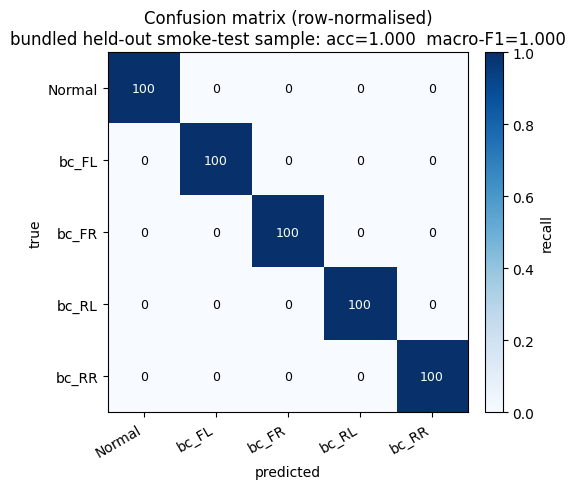

In [6]:
fig, ax = plt.subplots(figsize=(5.6, 5))
cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
im = ax.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS, rotation=30, ha='right')
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title(f'Confusion matrix (row-normalised)\n{EVAL_LABEL}: acc={acc:.3f}  macro-F1={macro_f1:.3f}')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f'{cmn[i,j]*100:.0f}', ha='center', va='center',
                color='white' if cmn[i,j] > 0.5 else 'black', fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='recall')
plt.tight_layout(); plt.show()

## 5 · Inference demo — watching one scenario cross the fault

Like the classic "swap the image, read the prediction" demo, but the *image* is a 0.5 s
window of residual signals sliding along one run. As the window crosses the fault
injection at **t = 6 s**, the predicted class flips from **Normal** to the wheel's fault
class. Below we run every window of a single held-out `bc_RR` scenario and plot the
predicted-class probability over time.

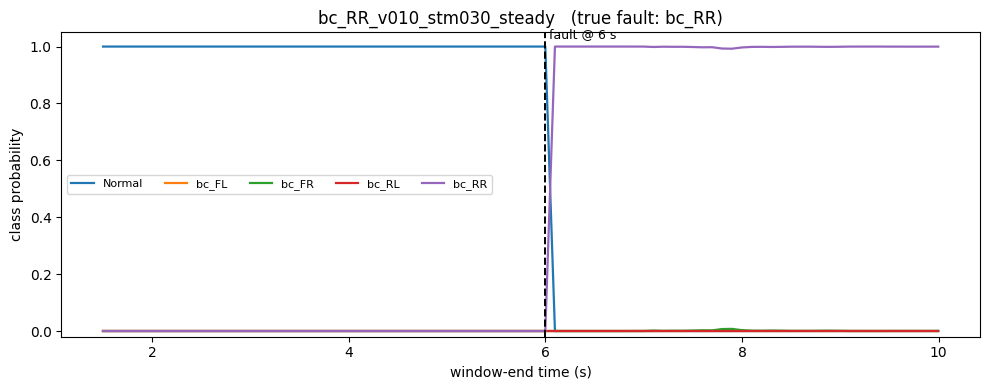

windows before 6s  -> predicted: ['Normal']
windows after  6s  -> predicted: ['bc_RR']


In [7]:
demo_path = next(Path(p) for p in eval_paths if Path(p).stem.startswith('bc_RR'))
w, l, tend = extract(demo_path)
x = (torch.from_numpy(w).to(device) - mean) / std
with torch.no_grad():
    prob = torch.softmax(model(x), dim=1).cpu().numpy()
pred = prob.argmax(1)
true_cls = _fault_class_from_name(demo_path)

fig, ax = plt.subplots(figsize=(10, 4))
for c in range(NUM_CLASSES):
    ax.plot(tend, prob[:, c], lw=1.6, label=CLASS[c])
ax.axvline(6.0, color='k', ls='--', lw=1.4)
ax.text(6.0, 1.02, ' fault @ 6 s', fontsize=9, va='bottom')
ax.set_xlabel('window-end time (s)'); ax.set_ylabel('class probability')
ax.set_ylim(-0.02, 1.05)
ax.set_title(f'{demo_path.stem}   (true fault: {CLASS[true_cls]})')
ax.legend(ncol=5, fontsize=8, loc='center left')
plt.tight_layout(); plt.show()

before = pred[tend < 6.0]
after  = pred[tend >= 6.0]
print('windows before 6s  -> predicted:', [CLASS[c] for c in np.unique(before)])
print('windows after  6s  -> predicted:', [CLASS[c] for c in np.unique(after)])

## 6 - Summary

| Metric | Target | Released checkpoint (full test) |
|--------|--------|--------------------------------|
| Accuracy | > 0.95 | **0.9524** |
| Macro-F1 | > 0.90 | **0.918** |

Per-class F1 (full test): Normal 1.000; bc_FL 0.902; bc_FR 0.890; bc_RL 0.911; bc_RR 0.887.

The released 1-D CNN meets the project targets on the full held-out test set according
to the saved checkpoint metadata. This submitted notebook is portable: it loads the
bundled checkpoint, evaluates a small held-out smoke-test sample included in
`final_project_assets/sample_data`, and demonstrates live window-by-window inference
flipping at the fault-injection time. Set `USE_FULL_DATA_IF_AVAILABLE = True` to run
the same notebook against the full local dataset.
